In [ ]:
import os
import cv2
import numpy as np
import shutil
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/agri"
categories = ['pineapple', 'Lemon', 'banana', 'coconut']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir(dataset_path)

['coconut', 'Lemon', 'banana', 'pineapple', 'train', 'test']

In [ ]:
for category in categories:
    category_path = os.path.join(dataset_path, category)
    if not os.path.exists(category_path) or len(os.listdir(category_path)) == 0:
        print(f"Warning: No images found in {category_path}. Skipping category.")
        continue  # Skip empty categories

    images = os.listdir(category_path)
    train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(train_path, category), exist_ok=True)
    os.makedirs(os.path.join(test_path, category), exist_ok=True)

    for img in train_images:
        shutil.move(os.path.join(category_path, img), os.path.join(train_path, category, img))
    for img in test_images:
        shutil.move(os.path.join(category_path, img), os.path.join(test_path, category, img))

print("Train/Test split done!")


Train/Test split done!


In [ ]:
all_descriptors = []
image_features = []
labels = []

for idx, category in enumerate(categories):
    category_path = os.path.join(train_path, category)
    for image_name in os.listdir(category_path):
        image_path = os.path.join(category_path, image_name)
        descriptors = extract_orb_features(image_path)
        if descriptors is not None:
            all_descriptors.extend(descriptors)
            image_features.append(descriptors)
            labels.append(idx)

In [ ]:
num_clusters = 300  # Increased for better feature representation
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(all_descriptors)

KMeans(n_clusters=300, n_init=10, random_state=42)

In [ ]:
def extract_bovw_features(image_descriptors, kmeans):
    histogram = np.zeros(num_clusters)
    cluster_assignments = kmeans.predict(image_descriptors)
    for cluster_id in cluster_assignments:
        histogram[cluster_id] += 1
    return histogram

image_histograms = np.array([extract_bovw_features(desc, kmeans) for desc in image_features])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(image_histograms, labels, test_size=0.2, random_state=42)
svm = SVC(kernel='rbf', C=10, gamma='scale')  # RBF kernel for better separation
svm.fit(X_train, y_train)

SVC(C=10)

In [ ]:
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Improved Classification Accuracy: {accuracy:.2f}")

Improved Classification Accuracy: 0.28


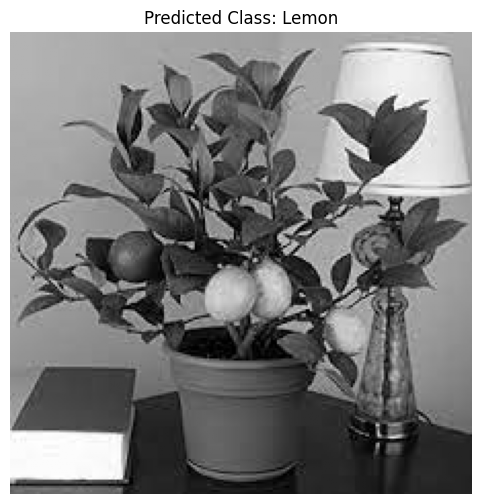

Predicted Class: Lemon


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_image(image_path, kmeans, scaler, svm_model, categories):
    # Step 1: Read and extract ORB features from the input image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: Image not found or unable to read.")
        return None

    descriptors = extract_orb_features(image_path)
    if descriptors is None:
        print("No keypoints detected in the image.")
        return None

    # Step 2: Convert descriptors to BoVW histogram
    bovw_features = extract_bovw_features(descriptors, kmeans)

    # Step 3: Normalize features using the same scaler
    bovw_features = scaler.transform([bovw_features])

    # Step 4: Predict class using the trained SVM model
    prediction = svm_model.predict(bovw_features)[0]
    predicted_class = categories[prediction]

    # Step 5: Plot the test image with predicted label
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Class: {predicted_class}")
    plt.axis("off")
    plt.show()

    return predicted_class

# 📌 Test with a New Image
test_image_path = "/content/drive/MyDrive/agri/train/Lemon/image27.jpeg"  # Change this path
predicted_class = predict_image(test_image_path, kmeans, scaler, svm, categories)
print(f"Predicted Class: {predicted_class}")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ani.jpeg to ani.jpeg


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cat.jpeg.png to cat.jpeg.png


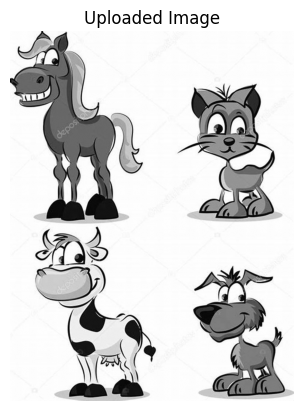

In [ ]:
import cv2

scene_img = cv2.imread("ani.jpeg", cv2.IMREAD_GRAYSCALE)
plt.imshow(scene_img, cmap='gray')
plt.title('Uploaded Image')
plt.axis('off')
plt.show()

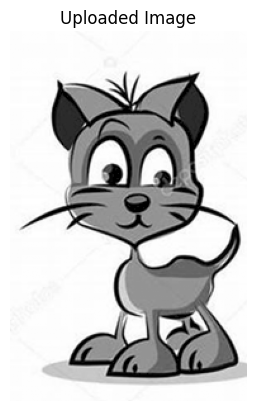

In [ ]:
object_img = cv2.imread("cat.jpeg.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(object_img, cmap='gray')
plt.title('Uploaded Image')
plt.axis('off')
plt.show()

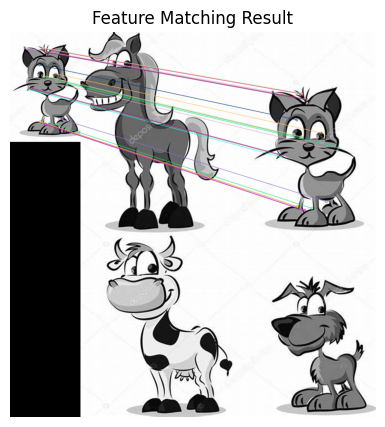

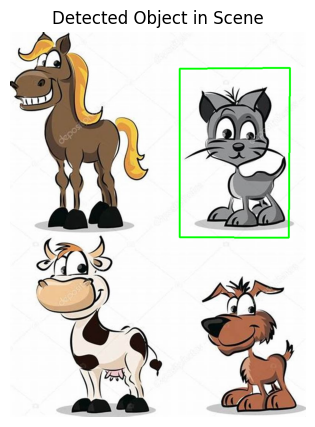

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the images
scene_img = cv2.imread("ani.jpeg", cv2.IMREAD_GRAYSCALE)  # Scene with multiple animals
object_img = cv2.imread("cat.jpeg.png", cv2.IMREAD_GRAYSCALE)  # Cat template

# Initialize ORB detector
orb = cv2.ORB_create()

# Extract matched keypoints
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# Find homography
if len(matches) > 10:
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    h, w = object_img.shape
    corners = np.float32([[0, 0], [0, h], [w, h], [w, 0]]).reshape(-1, 1, 2)
    transformed_corners = cv2.perspectiveTransform(corners, M)
    scene_img_color = cv2.imread("ani.jpeg")
    cv2.polylines(scene_img_color, [np.int32(transformed_corners)], True, (0, 255, 0), 3)

    # Show the segmented object
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(scene_img_color, cv2.COLOR_BGR2RGB))
    plt.title("Detected Object in Scene")
    plt.axis("off")
    plt.show()
else:
    print("Not enough matches found to detect the object.")


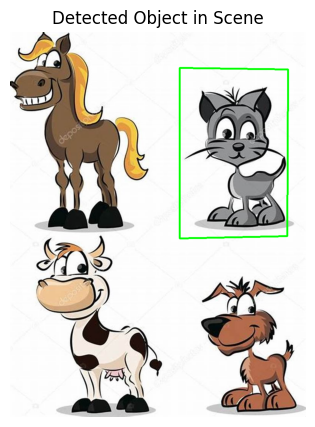

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the images
scene_img = cv2.imread("ani.jpeg", cv2.IMREAD_GRAYSCALE)  # Scene with multiple animals
object_img = cv2.imread("cat.jpeg.png", cv2.IMREAD_GRAYSCALE)  # Cat template

# Initialize ORB detector
orb = cv2.ORB_create()

# Find keypoints and descriptors
kp1, des1 = orb.detectAndCompute(object_img, None)
kp2, des2 = orb.detectAndCompute(scene_img, None)

# Use BFMatcher for feature matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches = bf.knnMatch(des1, des2, k=2)

# Apply Lowe’s ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)
matches = good_matches

# Extract matched keypoints
src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)


# Find homography
if len(matches) > 5:
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    h, w = object_img.shape
    corners = np.float32([[0, 0], [0, h], [w, h], [w, 0]]).reshape(-1, 1, 2)
    transformed_corners = cv2.perspectiveTransform(corners, M)
    scene_img_color = cv2.imread("ani.jpeg")
    cv2.polylines(scene_img_color, [np.int32(transformed_corners)], True, (0, 255, 0), 3)

    # Show the detected object in the scene
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(scene_img_color, cv2.COLOR_BGR2RGB))
    plt.title("Detected Object in Scene")
    plt.axis("off")
    plt.show()
